In [1]:
import numpy as np
import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

In [2]:
graph = ds.load_graph(
    from_assay="RNA",
    cell_key="I",
    feat_key="hvgs",
    symmetric=True,
    upper_only=False,
)
graph_strength = np.asarray(graph.sum(axis=1)).ravel()
ds.cells.insert(
    column_name="customGraphStrength",
    values=graph_strength,
    key="I",
    overwrite=True,
)
{
    "cells": int(graph.shape[0]),
    "edges": int(graph.nnz),
    "customGraphStrength mean": float(graph_strength.mean()),
}

{'cells': 3940, 'edges': 64464, 'customGraphStrength mean': 10.024938583374023}

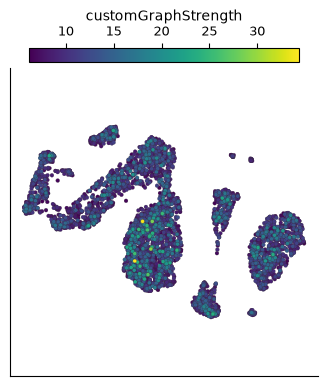

In [3]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="customGraphStrength",
    sort_values=True,
)

In [4]:
cell_index = ds.cells.active_index("I")
feature_index = ds.RNA.feats.active_index("I__hvgs")
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

detected_blocks = []
for count_block in selected_counts.stream_blocks(
    nthreads=4,
    msg="Calculating custom detection statistic",
):
    detected_blocks.append(np.count_nonzero(count_block, axis=1))

detected_hvgs = np.concatenate(detected_blocks)
ds.cells.insert(
    column_name="customDetectedHVGs",
    values=detected_hvgs,
    key="I",
    overwrite=True,
)
{
    "cells": int(detected_hvgs.size),
    "customDetectedHVGs mean": float(detected_hvgs.mean()),
    "customDetectedHVGs max": int(detected_hvgs.max()),
}

Calculating custom detection statistic: 2 / 2 complete

{'cells': 3940,
 'customDetectedHVGs mean': 135.85862944162437,
 'customDetectedHVGs max': 250}

In [5]:
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)

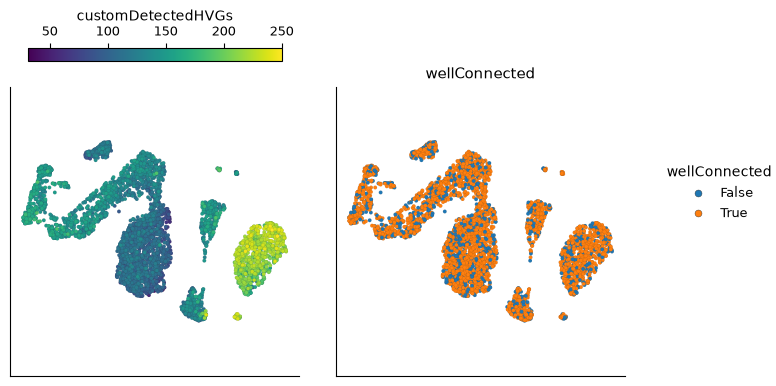

In [6]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["customDetectedHVGs", "wellConnected"],
    n_columns=2,
    sort_values=True,
)

In [7]:
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
panel_mask = np.isin(feature_names, panel_genes)
custom_feature_key = ds.set_hvgs(
    cell_key="wellConnected",
    mask=panel_mask,
    hvg_key_name="customPanel",
    blacklist="",
)
custom_feature_key, int(ds.RNA.feats.fetch_all(custom_feature_key).sum())

Computing RNA feature statistics: 6 / 6 complete

('wellConnected__customPanel', 6)

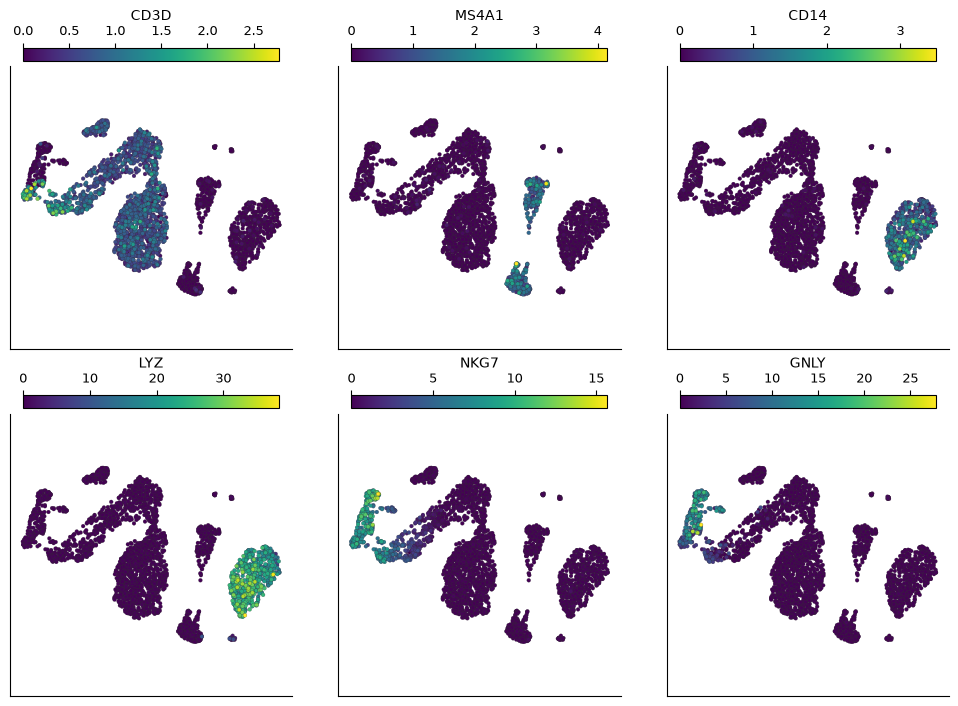

In [8]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=panel_genes,
    cell_key="wellConnected",
    n_columns=3,
    sort_values=True,
)

In [9]:
branch_normalized = ds.run_normalization(
    cell_key="wellConnected",
    feat_key="customPanel",
    update_state=False,
)
n_features = int(ds.load_artifact(branch_normalized)["data"].shape[1])
external_loadings = np.eye(n_features, dtype=np.float64)

custom_reduction = ds.run_custom_reduction(
    external_loadings,
    branch_normalized,
    update_state=False,
)
custom_ann = ds.build_ann_index(
    custom_reduction,
    update_state=False,
)
ds.load_artifact(custom_reduction)["data"].shape, custom_ann

Writing data: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

((2955, 6),
 ArtifactRef(assay='RNA', kind='ann_index', artifact_id='b3b3ad24521e...'))

In [10]:
adata = ds.to_anndata(
    cell_key="wellConnected",
    feature_names=panel_genes,
)
adata.shape, adata.var_names.tolist()

Converting RNA raw data to CSR: 2 / 2 complete

((2955, 6),
 ['ENSG00000167286',
  'ENSG00000156738',
  'ENSG00000170458',
  'ENSG00000090382',
  'ENSG00000105374',
  'ENSG00000115523'])

In [11]:
from pathlib import Path
import shutil

subset_path = Path("scarf_datasets/custom_analyses_subset.zarr")
if subset_path.exists():
    shutil.rmtree(subset_path)

writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="wellConnected",
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset_ds = scarf.DataStore(str(subset_path))
{
    "source wellConnected cells": int(ds.cells.fetch_all("wellConnected").sum()),
    "subset cells": subset_ds.cells.N,
    "subset RNA features": subset_ds.RNA.feats.N,
}

Subsetting assay: RNA: 2 / 2 complete

Computing RNA initialization statistics: 2 / 2 complete

{'source wellConnected cells': 2955,
 'subset cells': 2955,
 'subset RNA features': 33538}